In [1]:
import sys
import numpy as np

import src as scit
import anndata as ad
import polars as pl
import pandas as pd

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

Info: Passing entries (> 2.36): 7493594 (20.03%)


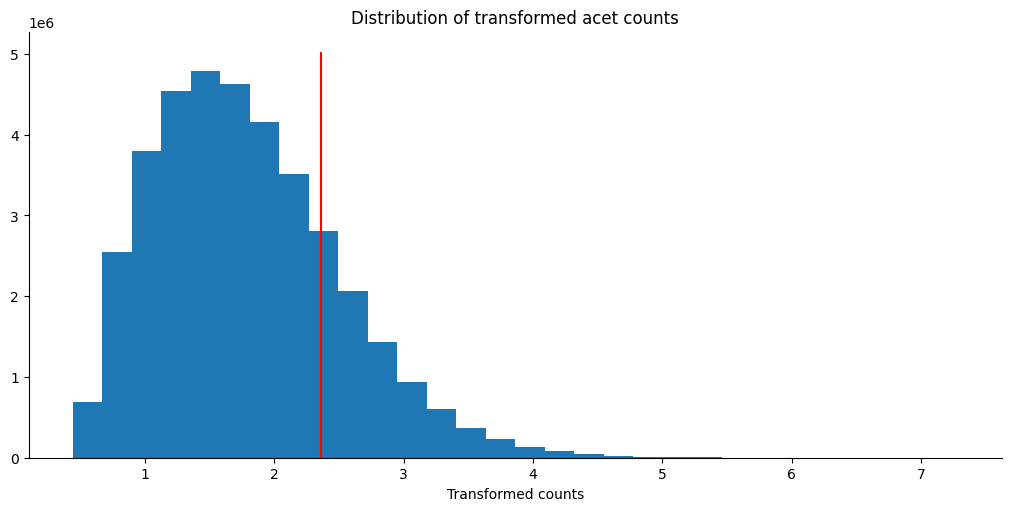

In [28]:
layer = 'acet'
lc = scit.tl.make_layer_config(
    layer,
    log_transform=True,
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet'],
    feature_active_threshold=3.5 if layer == 'meth' else 2.36 # Top 10 million 
    #2.921 if layer == 'meth' else 2.179 # Top k million
)
scit.pl.layer_config_histogram(cttag, lc)

In [29]:
#scit.tl.layer_pick_features(cttag, lc_acet, 'Oli')

# threshold = int(cttag.shape[0] * 0.02)
# scit.tl.layer_pick_features(cttag, lc, 0, after_binarization=True, filter_min = threshold)
# mask = lc.cached_mask.copy()
scit.adv.neighborhood_activities(
    cttag,
    lc,
    community_matrix='random_matrix',
    use_cached_mask=False
)
import gc; gc.collect()

Info: Added to .obsm["neighborhood_acet"], .uns["neighborhood_acet_names"]


35979

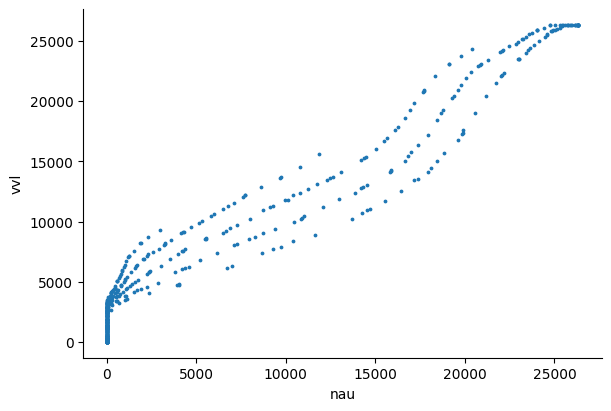

In [33]:
lc_semiactive = scit.tl.make_layer_config(f'neighborhood_{lc.layer}', in_obsm=True, feature_names=cttag.uns[f'neighborhood_{lc.layer}_names'])

scit.set_defaults(figsize=(6,4))
#METH:
copied = {}
# for gn in ['Act5C', 'vvl', 'nau', 'GATAe', 'acj6', 'Abd-B']:
tocheck = ['nau', 'vvl']
#tocheck = ['nau', 'GATAe']
for gn in tocheck:
    scit.tl.layer_pick_features(cttag, lc_semiactive, gn)
    scit.tl.copy_to_obs(cttag, lc_semiactive, binarize=False)
    copied[gn] = cttag.obs['copied_data'].copy()

import matplotlib.pyplot as plt
q = np.median(np.unique(cttag.obs['label'],return_counts=True)[1]/cttag.shape[0])

res = {tocheck[0]: [], tocheck[1]: []}
rese = []

i = 0
for _a in [0,0.05,0.1,0.15,0.2,0.3,0.4]:
    for _g in [0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
        for _b in [0.5,1,1.5,1.7,1.9,2.2,2.4,2.6,3,3.2,3.5]:
            i+= 1
            for k,v in copied.items():
                
                cttag.obs['copied_data'] = ((v - _a) / (np.power(1+np.quantile(v,q), _g)-1)) > _b
                res[k].append(cttag.obs['copied_data'].sum())
            rese.append([_a,_g,_b])
resa = np.c_[res[tocheck[0]], res[tocheck[1]]]
scit.pl.int.scatter(resa,xlabel=tocheck[0],ylabel=tocheck[1])

In [34]:
#check1 = np.array(rese)[(np.array(resa)[:,0] > 10000) * (np.array(resa)[:,1] < 5000)]
check1 = np.array(rese)[(np.array(resa)[:,0] < 8000) * (np.array(resa)[:,1] > 5000)]
check1.shape

(81, 3)

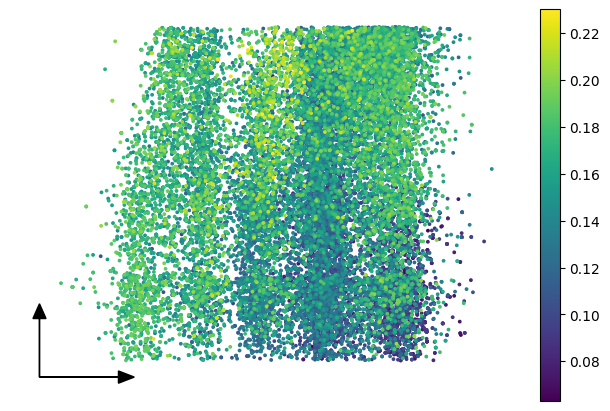

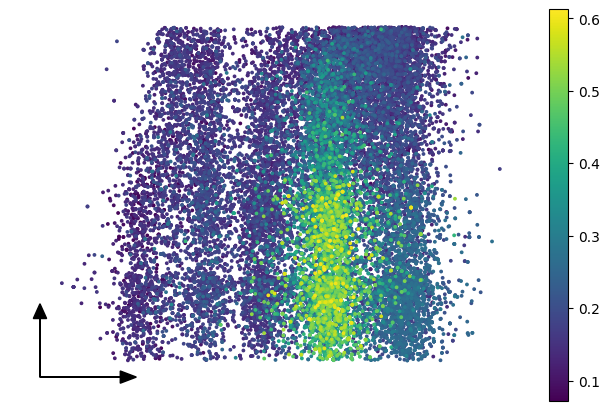

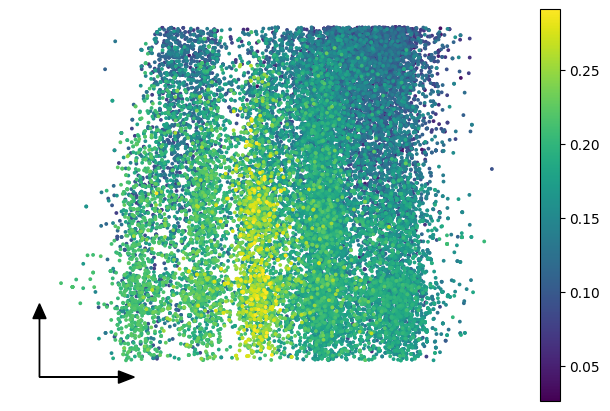

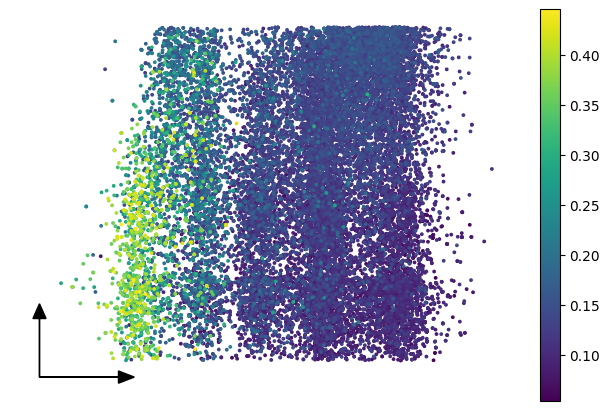

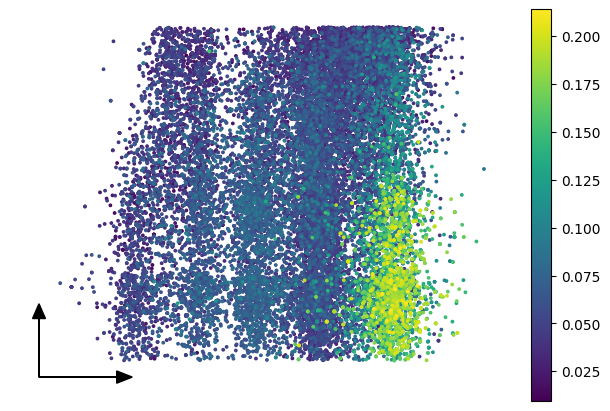

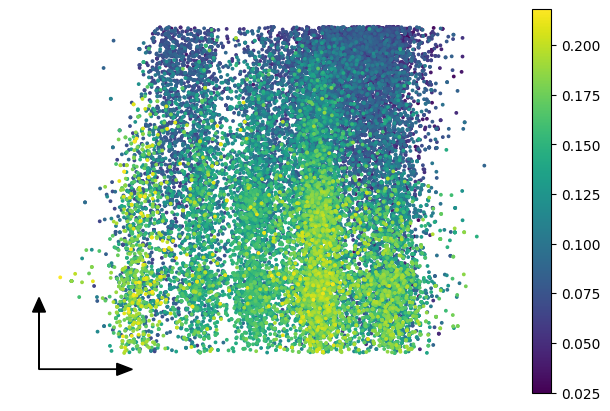

In [35]:
lc_semiactive = scit.tl.make_layer_config(f'neighborhood_{lc.layer}', in_obsm=True, feature_names=cttag.uns[f'neighborhood_{lc.layer}_names'])

scit.set_defaults(figsize=(6,4))

copied = {}
for gn in ['Act5C', 'vvl', 'nau', 'GATAe', 'acj6', 'Abd-B']:
    #scit.tl.layer_pick_features(cttag, lc, gn)
    #scit.tl.copy_to_obs(cttag, lc, binarize=True)
    #scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data')
    scit.tl.layer_pick_features(cttag, lc_semiactive, gn)
    scit.tl.copy_to_obs(cttag, lc_semiactive, binarize=False)
    scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data')
    copied[gn] = cttag.obs['copied_data'].copy()

import matplotlib.pyplot as plt
q = np.median(np.unique(cttag.obs['label'],return_counts=True)[1]/cttag.shape[0])

i = 0
for _a,_g,_b in check1:
    i+= 1
    for k,v in copied.items():
        
        #scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', vminmax=(0,1))
        cttag.obs['copied_data'] = ((v - _a) / (np.power(1+np.quantile(v,q), _g)-1)) > _b
        scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', vminmax=(0.9,1), show=False).savefig(f'private/hyper_acet/{i}_a={_a},g={_g},b={_b},{k}.png')
        plt.close('all')

Info: Added to .obsm["neighborhood_acet_active"]


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/_distances.py:171: RuntimeWarning: divide by zero encountered in divide
  adata.obsm[s] = (X @ sps.diags(1.0 / mean)) > enrich_b


Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_helper.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=self.figsize)


Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]
Info: Added to .obsm["neighborhood_acet_active"]


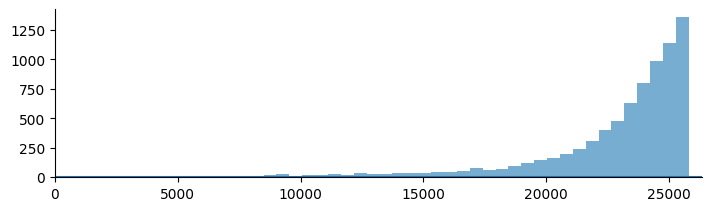

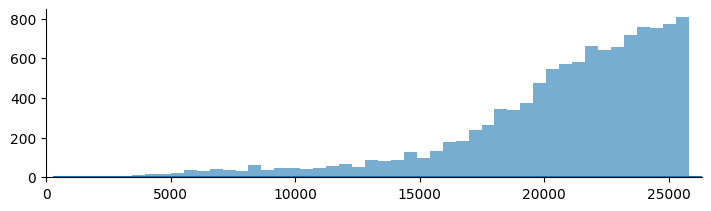

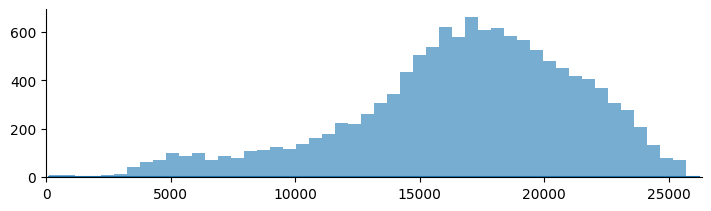

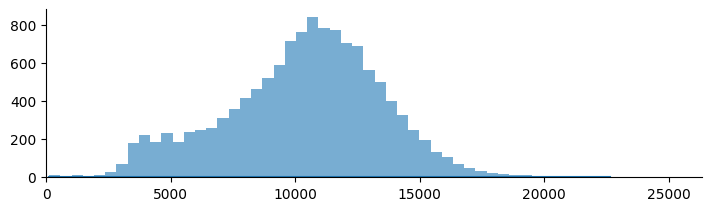

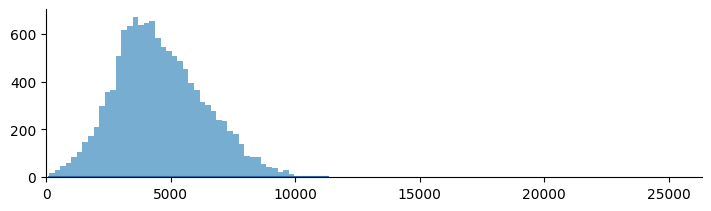

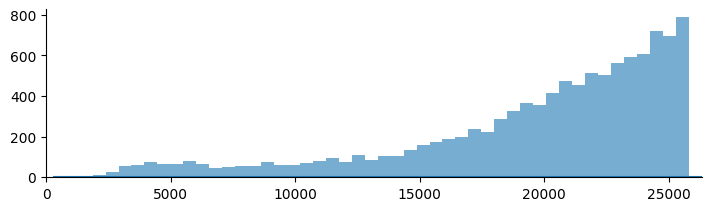

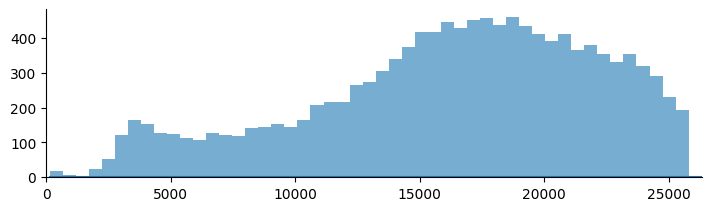

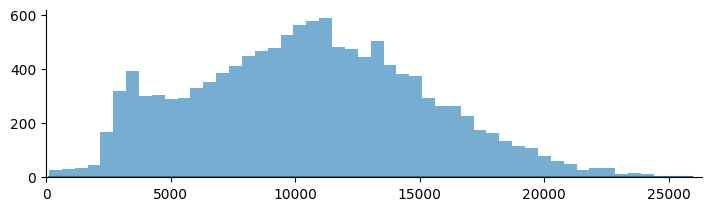

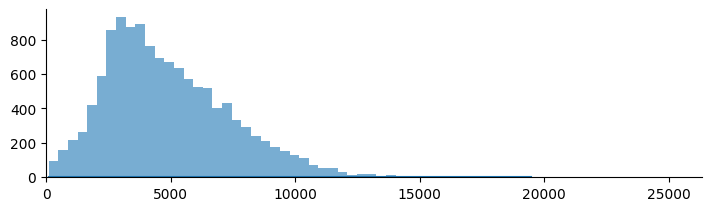

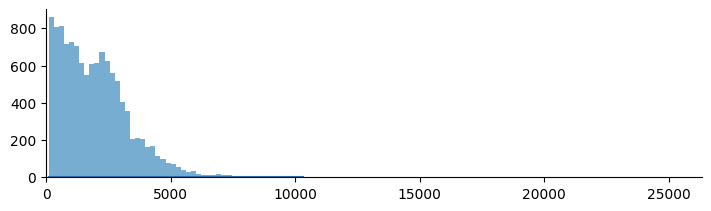

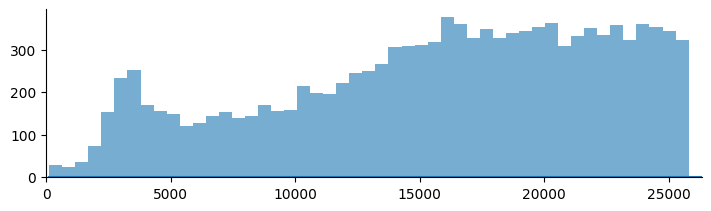

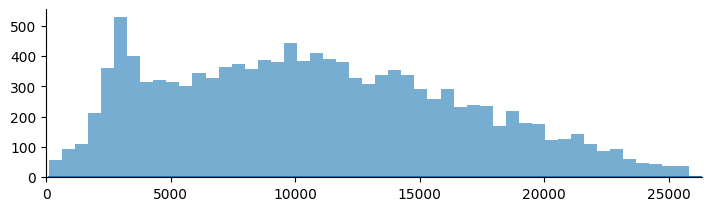

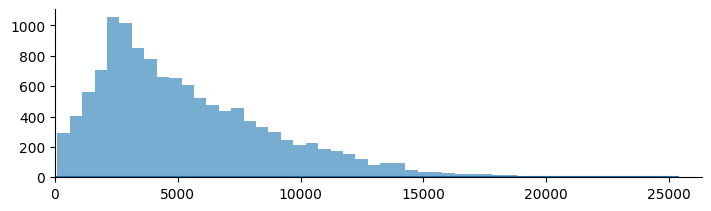

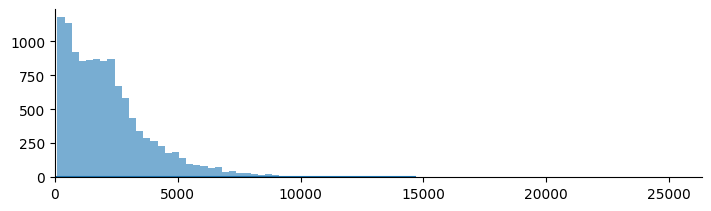

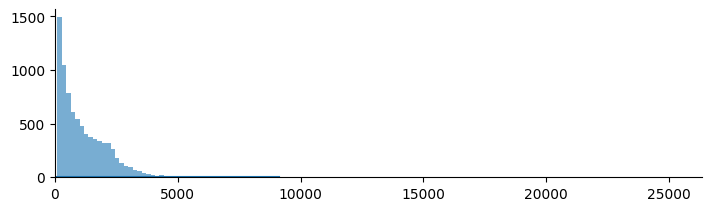

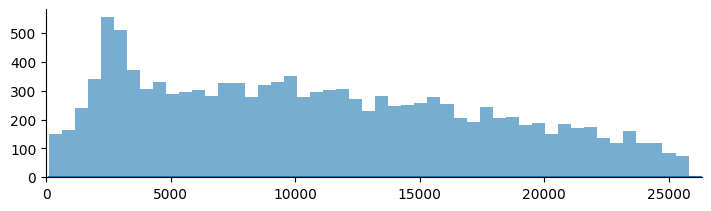

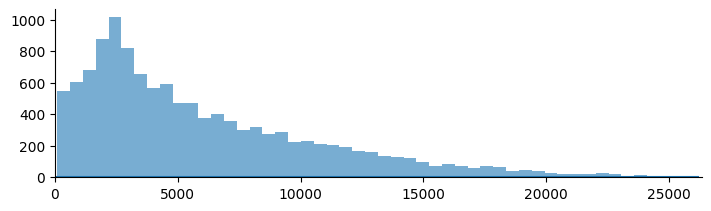

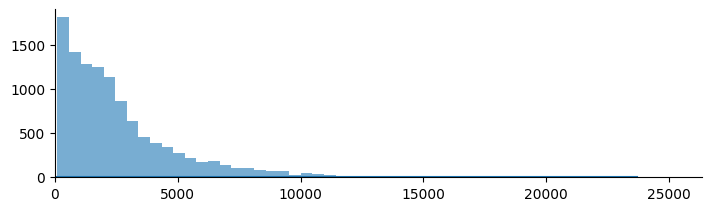

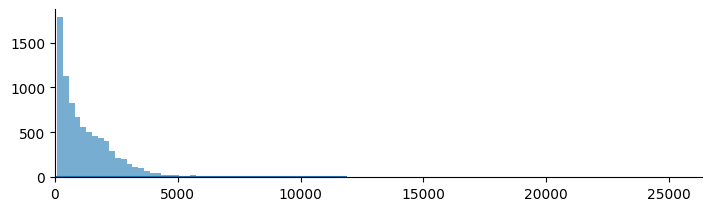

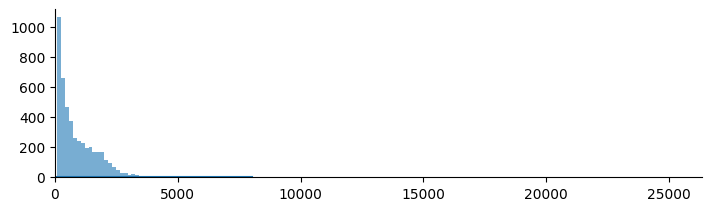

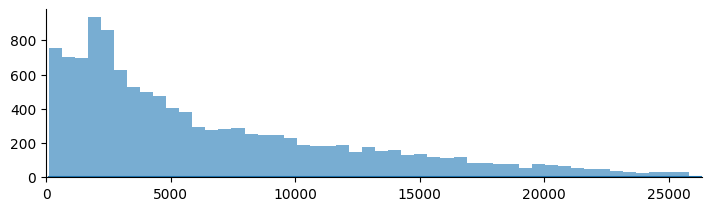

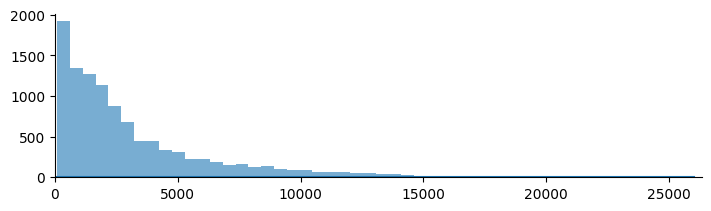

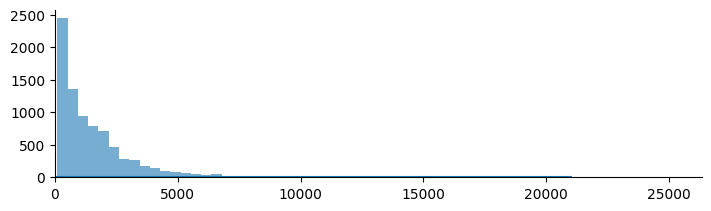

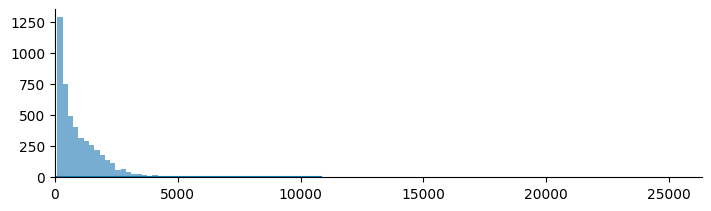

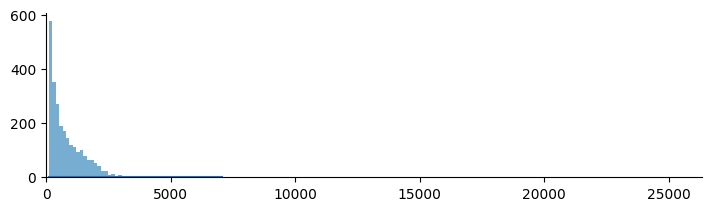

In [8]:
lc_active = scit.tl.make_layer_config(f'neighborhood_{layer}_active', in_obsm=True, feature_names=cttag.uns[f'neighborhood_{layer}_names'])
scit.set_defaults(figsize=(7,2))

_possible_a = [0.04, 0.07, 0.1, 0.13, 0.16]
_possible_b = [0.2, 0.4, 0.6, 0.8, 1]

for _a in _possible_a:
    for _b in _possible_b:
        scit.adv.classify_enrichment(
            cttag,
            lc_semiactive,
            enrich_a=_a,
            enrich_b=_b
        )

        sums = lc_active.transform(cttag).sum(axis=0).A1
        # print(np.arange(len(sums))[(sums>1500) * (sums < 2000)])
        sums = sums[sums > 100]
        scit.pl.int.histogram(sums,kde=True, bins=50, show=False, xminmax=(0,cttag.shape[0])).savefig(f'private/hyper_acet/a={_a},b={_b}.png')
        del cttag.obsm[f'neighborhood_{layer}_active']
        import gc; gc.collect()